"""Batch-process all attached sessions in this workstation.

Shift+Enter through cells. CELL 0 (optional) auto-attaches recent data assets
via the CodeOcean API — requires a workstation restart to take effect.
CELL 2 discovers every (raw, processed) pair currently mounted at /data/;
CELL 3 loops through them and writes per-session outputs to
/results/<subject>_<date>_<stem>/.

When you stop the workstation, choose "save results" to capture
/results/ as a CO data asset with all sessions inside.

To process only a subset, edit `TARGETS` in CELL 2 to a hand-picked list.
"""

In [25]:
import os, json, subprocess, re, sys, logging, traceback
import numpy as np
from pathlib import Path

sys.path.insert(0, "/code")
import extract_scanimage_metadata
import data_dict_create_module_bruker
import bonsai_npy_threshold_calculator
ddc = data_dict_create_module_bruker

%matplotlib inline
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
import matplotlib.pyplot as plt

CN_THRESHOLD_PERCENTILE = 95   # set to None to disable the threshold line

def find_pair_in_data(subject: str, date: str):
    """Return (raw_path, proc_path, proc_root) for the given subject+date in /data/.
    Raises if not found or ambiguous."""
    asset_prefix = f"single-plane-ophys_{subject}_{date}_"
    attached = sorted(Path("/data").iterdir())
    raws = [p for p in attached if p.name.startswith(asset_prefix) and "_processed_" not in p.name]
    procs = [p for p in attached if p not in raws and subject in p.name and date in p.name]

    if not raws:
        raise RuntimeError(f"No raw asset for {subject}/{date}. Attached: {[p.name for p in attached]}")
    if len(raws) > 1:
        raise RuntimeError(f"Multiple raw assets for {subject}/{date}: {[r.name for r in raws]}")
    raw = raws[0]

    if not procs:
        raise RuntimeError(f"No processed asset for {subject}/{date}")

    def _ts(p):
        m = re.search(r"_processed_(\d{4}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2})", p.name)
        return m.group(1) if m else ""
    procs_sorted = sorted(procs, key=_ts, reverse=True)
    proc = procs_sorted[0]

    if (proc / "extraction").is_dir():
        proc_root = proc
    else:
        candidates = [c for c in proc.iterdir() if c.is_dir() and (c / "extraction").is_dir()]
        if not candidates:
            raise RuntimeError(f"No extraction/ inside {proc.name}")
        proc_root = candidates[0]
    return raw, proc, proc_root


def process_session(subject: str, date: str, target_stem: str):
    """Build workspace + run ddc + run bonsai for one session.

    Outputs flat at /results/:
      /results/<subject>_<date>_<stem>.h5
      /results/figures/<subject>_<date>_<stem>_fig_NN.png
    """
    session_tag = f"{subject}_{date}_{target_stem}"
    workspace = Path(f"/scratch/{session_tag}")
    pophys = workspace / "pophys"
    results_root = Path("/results")
    figures_dir = results_root / "figures"
    results_root.mkdir(parents=True, exist_ok=True)
    figures_dir.mkdir(exist_ok=True)

    raw, proc, proc_root = find_pair_in_data(subject, date)
    extraction = proc_root / "extraction"
    mc = proc_root / "motion_correction"
    print(f"  raw:  {raw.name}")
    print(f"  proc: {proc.name}")

    # Resolve target epoch with fallback to base stem (e.g. bci2 -> bci)
    with open(mc / "epoch_locations.json") as f:
        epoch_locations = json.load(f)
    with open(mc / "trial_locations.json") as f:
        trial_locations = json.load(f)

    if target_stem not in epoch_locations:
        base = target_stem.rstrip("0123456789") or target_stem
        candidates = sorted(k for k in epoch_locations if base in k)
        if not candidates:
            raise RuntimeError(f"Epoch {target_stem!r} not found. Available: {list(epoch_locations)}")
        resolved = base if base in epoch_locations else candidates[0]
        print(f"  NOTE: {target_stem!r} not in epochs; using {resolved!r}")
        target_stem = resolved

    target_start, target_end = epoch_locations[target_stem]

    # Build workspace
    subprocess.run(["rm", "-rf", str(workspace)], check=False)
    pophys.mkdir(parents=True)

    # Build behavior directory: symlink everything, but repair SoftwareEvents/*.json.
    # These files are newline-delimited JSON (one object per line). When a session
    # ends abruptly, the last line of every SoftwareEvents file is truncated — a
    # single json.loads() failure crashes bonsai. Drop bad lines and write clean copies.
    # Logs/ files are whole-file JSON (not NDJSON) so they are symlinked as-is.
    behavior_src = raw / "behavior"
    behavior_dst = workspace / "behavior"
    for src_path in behavior_src.rglob("*"):
        rel = src_path.relative_to(behavior_src)
        dst_path = behavior_dst / rel
        if src_path.is_dir():
            dst_path.mkdir(parents=True, exist_ok=True)
        elif src_path.suffix == ".json" and rel.parts[0] == "SoftwareEvents":
            lines = src_path.read_text(errors="replace").splitlines()
            good, skipped = [], 0
            for line in lines:
                line = line.strip()
                if not line:
                    continue
                try:
                    json.loads(line)
                    good.append(line)
                except json.JSONDecodeError:
                    skipped += 1
            if skipped:
                print(f"  {rel}: dropped {skipped} malformed line(s)")
            dst_path.write_text("\n".join(good) + "\n")
        else:
            if not dst_path.exists():
                dst_path.symlink_to(src_path)

    target_tifs = sorted(
        name for name, (s, e) in trial_locations.items()
        if name.startswith(f"{target_stem}_") and s >= target_start and e <= target_end
    )
    frames_per_file = [trial_locations[n][1] - trial_locations[n][0] + 1 for n in target_tifs]
    print(f"  {len(target_tifs)} TIFFs ({sum(frames_per_file)} frames)")

    # No need to symlink TIFFs — nothing in ddc.main / bonsai reads them
    # from the workspace. We extract siHeader directly from the raw asset.
    # Sidecar files (csv, mat) ARE used by ddc.main, so symlink those.
    for f in (raw / "pophys").iterdir():
        if f.is_file() and f.suffix not in (".tif", ".stim") and f.name.startswith(f"{target_stem}_"):
            tgt = pophys / f.name
            if not tgt.exists():
                tgt.symlink_to(f)

    bci_dir = pophys / "suite2p_BCI" / "plane0"
    bci_dir.mkdir(parents=True)
    frame_slice = slice(target_start, target_end + 1)

    # Set up spont_pre dir upfront so we can write both slices in one load pass.
    has_spont = "spont_pre" in epoch_locations
    if has_spont:
        s_start, s_end = epoch_locations["spont_pre"]
        spont_dir = pophys / "suite2p_spont_pre" / "plane0"
        spont_dir.mkdir(parents=True)
        s_slice = slice(s_start, s_end + 1)

    # Single pass: load each array once with mmap_mode so only the sliced
    # columns are read into RAM, then write both output slices before freeing.
    for fname in ["F", "Fneu", "spks"]:
        src_path = extraction / f"{fname}.npy"
        if src_path.exists():
            arr = np.load(src_path, mmap_mode="r")   # memory-mapped: no full load
            np.save(bci_dir / f"{fname}.npy", arr[:, frame_slice])
            if has_spont:
                np.save(spont_dir / f"{fname}.npy", arr[:, s_slice])
            del arr   # release mmap handle

    for fname in ["stat.npy", "iscell.npy"]:
        src = extraction / fname
        if src.exists():
            (bci_dir / fname).symlink_to(src)
            if has_spont:
                (spont_dir / fname).symlink_to(src)

    ops_path = extraction / "ops.npy"
    ops = np.load(ops_path, allow_pickle=True).tolist()
    ops["frames_per_file"] = frames_per_file
    np.save(bci_dir / "ops.npy", ops)

    # Read siHeader directly from the raw asset — no need to symlink the TIFF.
    first_tif = raw / "pophys" / target_tifs[0]
    siHeader = extract_scanimage_metadata.extract_scanimage_metadata(str(first_tif))
    siHeader["siBase"] = {0: target_stem, 1: "", 2: "spont_pre"}
    siHeader["savefolders"] = {0: target_stem, 1: "spont", 2: "spont_post", 3: "spont_pre", 4: "spont_post"}
    np.save(bci_dir / "siHeader.npy", siHeader)

    # Run ddc.main
    folder = str(pophys) + "/"
    data = ddc.main(folder)
    m = re.match(r"single-plane-ophys_(\d+)_(\d{4}-\d{2}-\d{2})_", raw.name)
    if m:
        data["mouse"] = m.group(1)
        data["session"] = m.group(2)

    # Run bonsai
    try:
        figs = bonsai_npy_threshold_calculator.run(folder, data)
    except Exception as e:
        print(f"  bonsai failed: {e}")
        figs = []
    finally:
        del data   # ddc data dict may hold large F-like arrays; free it now

    # H5 stays in /scratch/<session>/pophys/data_main_*_BCI.h5 (ddc.main
    # already wrote it there). Not copied to /results/.

    # Apply 2/98 percentile clip to all heatmap images in every figure.
    for fig in figs:
        for ax in fig.get_axes():
            for im in ax.get_images():
                arr = im.get_array()
                if arr is None:
                    continue
                arr = np.asarray(arr)
                if arr.ndim == 2:
                    vmin = np.nanpercentile(arr, 2)
                    vmax = np.nanpercentile(arr, 98)
                    im.set_clim(vmin, vmax)

    if figs:
        ax0 = figs[0].get_axes()[0]

        # Fix hit rate y-axis to [0, 1] and re-anchor switch ticks
        ax0.set_ylim(0, 1)
        for line in ax0.get_lines():
            xdata = line.get_xdata()
            if len(xdata) == 2 and xdata[0] == xdata[1] and line.get_linewidth() < 1:
                line.set_ydata([0, 0.12])
                line.set_linewidth(2.0)

        # Random-walk learning threshold on CN activity subplot (axes[3]).
        # Null: symmetric random walk with the same step-size distribution as
        # the smoothed CN trace. Threshold = 95th percentile of the maximum
        # positive excursion across 5000 simulated walks of the same length.
        # If the CN trace peaks above this line it is implausible under the null
        # and the session is flagged as suspected learning.
        ax_cn = figs[0].get_axes()[3]
        cn_lines = [l for l in ax_cn.get_lines() if len(l.get_ydata()) > 1]
        if cn_lines and CN_THRESHOLD_PERCENTILE is not None:
            y = np.array(cn_lines[0].get_ydata())
            diff_y = np.diff(y)
            sigma = np.median(np.abs(diff_y - np.median(diff_y))) * 1.4826
            sigma = max(sigma, 1e-6)
            rng = np.random.default_rng(42)
            T = len(y)
            walks = np.concatenate([
                np.zeros((5000, 1)),
                np.cumsum(rng.normal(0, sigma, (5000, T - 1)), axis=1)
            ], axis=1)
            range_null = np.percentile(
                np.max(walks, axis=1) - np.min(walks, axis=1), CN_THRESHOLD_PERCENTILE
            )
            threshold_y = np.min(y) + range_null
            ylo, yhi = ax_cn.get_ylim()
            ax_cn.set_ylim(ylo, max(yhi, threshold_y * 1.05))
            ax_cn.axhline(threshold_y, color='r', linestyle='--',
                          linewidth=1.0, alpha=0.7)

        for fig in figs:
            fig.canvas.draw()   # flush all changes before savefig

    # Save all figures returned by bonsai.
    saved = 0
    for i, fig in enumerate(figs):
        out = figures_dir / f"{session_tag}_fig_{i:02d}.png"
        fig.savefig(out, dpi=150, bbox_inches="tight")
        saved += 1
    # Close all to free memory.
    for fig in figs:
        plt.close(fig)

    return figures_dir / f"{session_tag}_fig_00.png", saved

In [26]:
# Edit TARGETS below to override the auto-discovered list (e.g. to process
# just one session, or to set a non-default TARGET_STEM per session).

from datetime import date as _date, timedelta as _timedelta

# DATE_FILTER: only include sessions whose date field matches this string.
# Defaults to today. Set to None to include all attached dates.
DATE_FILTER = None
#DATE_FILTER = "2026-06-01"
# Build a set of the last 2 days
DATE_FILTER_DAYS = {
    _date.today().strftime("%Y-%m-%d"),
    (_date.today() - _timedelta(days=3)).strftime("%Y-%m-%d"),
}

def _best_bci_stem(proc_root):
    """Pick the bci stem with the most trial files.
    e.g. if 'bci' has 3 and 'bci2' has 140, returns 'bci2'."""
    trial_json = proc_root / "motion_correction" / "trial_locations.json"
    if not trial_json.exists():
        return "bci"
    with open(trial_json) as f:
        trial_locs = json.load(f)
    stem_counts = {}
    for name in trial_locs:
        parts = name.rsplit("_", 1)
        if len(parts) == 2:
            stem = parts[0]
            if re.match(r"bci\d*$", stem):
                stem_counts[stem] = stem_counts.get(stem, 0) + 1
    if not stem_counts:
        return "bci"
    best = max(stem_counts, key=stem_counts.get)
    if best != "bci":
        print(f"  {best!r} selected over 'bci' ({stem_counts})")
    return best

attached = sorted(Path("/data").iterdir())
print(f"Attached assets in /data ({len(attached)}):")
for p in attached:
    print(f"  {p.name}")

# Auto-discover (raw, proc) pairs
raws_all = [p for p in attached if p.name.startswith("single-plane-ophys_") and "_processed_" not in p.name]
auto_targets: list[tuple[str, str, str]] = []
for raw in raws_all:
    m = re.match(r"single-plane-ophys_(\d+)_(\d{4}-\d{2}-\d{2})_", raw.name)
    if not m:
        continue
    subject, date = m.group(1), m.group(2)
    # Skip sessions that don't match DATE_FILTER (set DATE_FILTER=None to disable)
    if date not in DATE_FILTER_DAYS:
        continue
    # Confirm a matching processed asset is also attached
    has_proc = any(
        p.name.startswith(raw.name + "_processed_") or
        (subject in p.name and date in p.name and "_processed_" in p.name)
        for p in attached
    )
    if has_proc:
        try:
            _, _, proc_root = find_pair_in_data(subject, date)
            stem = _best_bci_stem(proc_root)
        except Exception:
            stem = "bci"
        auto_targets.append((subject, date, stem))

# === Edit here to override ===
TARGETS = auto_targets   # default: process today's sessions
# Common overrides:
#   DATE_FILTER = None                                         # all attached dates
#   DATE_FILTER = "2026-05-27"                                 # specific date
#   TARGETS = [("850378", "2026-06-01", "bci")]                # specific session
#   TARGETS = [("850378", "2026-06-01", "bci"),
#              ("824468", "2026-06-01", "bci2")]               # multiple sessions
# ==============================

print(f"\nDate filter: {DATE_FILTER or 'none (all dates)'}")
print(f"Will process {len(TARGETS)} session(s):")
for sub, dt, stem in TARGETS:
    print(f"  {sub}  {dt}  stem={stem}")

Attached assets in /data (8):
  single-plane-ophys_820614_2026-06-04_10-12-49
  single-plane-ophys_820614_2026-06-04_10-12-49_processed_2026-06-04_21-58-07
  single-plane-ophys_824946_2026-06-04_11-13-31
  single-plane-ophys_824946_2026-06-04_11-13-31_processed_2026-06-04_19-55-27
  single-plane-ophys_857094_2026-06-03_10-39-18
  single-plane-ophys_857094_2026-06-03_10-39-18_processed_2026-06-03_22-53-28
  single-plane-ophys_857095_2026-06-03_11-22-19
  single-plane-ophys_857095_2026-06-03_11-22-19_processed_2026-06-03_23-01-58
  'bci2' selected over 'bci' ({'bci': 1, 'bci2': 61})

Date filter: none (all dates)
Will process 2 session(s):
  820614  2026-06-04  stem=bci
  824946  2026-06-04  stem=bci2


In [27]:
# Skip sessions whose PNG already exists. Re-running this cell is idempotent.
# Set FORCE = True to re-run sessions that already have a PNG.

import time, gc

FORCE = True

completed: list[dict] = []
skipped: list[dict] = []
failed: list[dict] = []
t0 = time.time()
figures_dir = Path("/results") / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

for subject, date, stem in TARGETS:
    session_tag = f"{subject}_{date}_{stem}"
    expected_png = figures_dir / f"{session_tag}_fig_00.png"

    if expected_png.exists() and not FORCE:
        print(f"  SKIP  {subject}  {date}  {stem}  (PNG already exists)")
        skipped.append({"subject": subject, "date": date, "stem": stem,
                        "png": str(expected_png)})
        continue

    print(f"\n{'='*70}")
    print(f"  {subject}  {date}  {stem}")
    print(f"{'='*70}")
    t_session = time.time()
    try:
        results_path, n_figs = process_session(subject, date, stem)
        dt = time.time() - t_session
        completed.append({"subject": subject, "date": date, "stem": stem,
                          "n_figures": n_figs, "png": str(results_path),
                          "elapsed_sec": round(dt, 1)})
        print(f"  -> {results_path}  ({n_figs} figs, {dt:.0f} sec)")
    except Exception as e:
        dt = time.time() - t_session
        failed.append({"subject": subject, "date": date, "stem": stem,
                       "error": str(e), "elapsed_sec": round(dt, 1)})
        print(f"  FAILED: {e}")
        traceback.print_exc()
    gc.collect()   # sweep any lingering refs from ddc/bonsai between sessions

t_total = time.time() - t0
print(f"\n{'='*70}")
print(f"Done in {t_total:.0f} sec.")
print(f"  completed: {len(completed)}")
print(f"  skipped:   {len(skipped)}  (PNG already existed; set FORCE=True to re-run)")
print(f"  failed:    {len(failed)}")
print(f"{'='*70}")
if failed:
    print("Failures:")
    for f in failed:
        print(f"  {f['subject']} {f['date']} {f['stem']}: {f['error']}")

# Save a batch summary alongside per-session outputs
with open(Path("/results") / "batch_summary.json", "w") as f:
    json.dump({"completed": completed, "skipped": skipped, "failed": failed,
               "total_sec": round(t_total, 1)}, f, indent=2)


  820614  2026-06-04  bci
  raw:  single-plane-ophys_820614_2026-06-04_10-12-49
  proc: single-plane-ophys_820614_2026-06-04_10-12-49_processed_2026-06-04_21-58-07
  198 TIFFs (126658 frames)
[bci] keeping 1 iscell==0 ROI(s) within 10 px of CN: [1316]


/opt/conda/lib/python3.9/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/conda/lib/python3.9/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/code/data_dict_create_module_bruker.py:385: RuntimeWarning: invalid value encountered in divide
  dff[i,:] = (Ftrace[i,:] - bl)/bl


No suite2p_ch1/plane0 folder found — skipping ch1 data.
Loading spont_pre data from /scratch/820614_2026-06-04_bci/pophys/suite2p_spont_pre
[bonsai] 198 Bonsai trials, 198 SI files, 198 matched
[MAIN] Non-photostim data saved as pickle: /scratch/820614_2026-06-04_bci/pophys/data_main_scratch_820614_2026-06-04_bci_BCI.npy
[MAIN] Non-photostim data saved as HDF5:   /scratch/820614_2026-06-04_bci/pophys/data_main_scratch_820614_2026-06-04_bci_BCI.h5
alpha = 1.0
alpha = 1.8802104625200677
alpha = 2.1242750413795637
alpha = 2.320340253063359
alpha = 2.524540950709137
alpha = 2.747453266067477
alpha = 2.989890747734576
alpha = 3.253480492902832


/code/bonsai_npy_threshold_calculator.py:255: RuntimeWarning: Mean of empty slice
  ff[:, ti] = ff[:, ti] - np.nanmean(ff[0:20, ti])
/code/bonsai_npy_threshold_calculator.py:258: RuntimeWarning: Mean of empty slice
  tuning_trial = np.nanmean(ff[60:, trim_start:], axis=0)
/code/bonsai_npy_threshold_calculator.py:284: RuntimeWarning: Mean of empty slice
  tuning = np.nanmean(ff[60:, :], axis=0)
/code/bonsai_npy_threshold_calculator.py:297: RuntimeWarning: Mean of empty slice
  b = b - np.nanmean(b[0:3])


  -> /results/figures/820614_2026-06-04_bci_fig_00.png  (2 figs, 94 sec)

  824946  2026-06-04  bci2
  raw:  single-plane-ophys_824946_2026-06-04_11-13-31
  proc: single-plane-ophys_824946_2026-06-04_11-13-31_processed_2026-06-04_19-55-27
  61 TIFFs (42906 frames)
[bci] keeping 1 iscell==0 ROI(s) within 10 px of CN: [311]


/opt/conda/lib/python3.9/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/conda/lib/python3.9/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/code/data_dict_create_module_bruker.py:385: RuntimeWarning: invalid value encountered in divide
  dff[i,:] = (Ftrace[i,:] - bl)/bl


No suite2p_ch1/plane0 folder found — skipping ch1 data.
Loading spont_pre data from /scratch/824946_2026-06-04_bci2/pophys/suite2p_spont_pre
[bonsai] 61 Bonsai trials, 61 SI files, 61 matched
[MAIN] Non-photostim data saved as pickle: /scratch/824946_2026-06-04_bci2/pophys/data_main_scratch_824946_2026-06-04_bci2_BCI.npy
[MAIN] Non-photostim data saved as HDF5:   /scratch/824946_2026-06-04_bci2/pophys/data_main_scratch_824946_2026-06-04_bci2_BCI.h5
alpha = 1.0
alpha = 1.4234324921486339


/code/bonsai_npy_threshold_calculator.py:255: RuntimeWarning: Mean of empty slice
  ff[:, ti] = ff[:, ti] - np.nanmean(ff[0:20, ti])
/code/bonsai_npy_threshold_calculator.py:258: RuntimeWarning: Mean of empty slice
  tuning_trial = np.nanmean(ff[60:, trim_start:], axis=0)
/code/bonsai_npy_threshold_calculator.py:284: RuntimeWarning: Mean of empty slice
  tuning = np.nanmean(ff[60:, :], axis=0)
/code/bonsai_npy_threshold_calculator.py:297: RuntimeWarning: Mean of empty slice
  b = b - np.nanmean(b[0:3])
/code/bonsai_npy_threshold_calculator.py:309: RuntimeWarning: Mean of empty slice
  plt.plot(x, np.nanmean(rt_epoch, axis=1), 'k.-')
/code/bonsai_npy_threshold_calculator.py:314: RuntimeWarning: Mean of empty slice
  plt.plot(x, np.nanmean(tuning_epoch, axis=1), 'k.-')


  -> /results/figures/824946_2026-06-04_bci2_fig_00.png  (2 figs, 31 sec)

Done in 125 sec.
  completed: 2
  skipped:   0  (PNG already existed; set FORCE=True to re-run)
  failed:    0


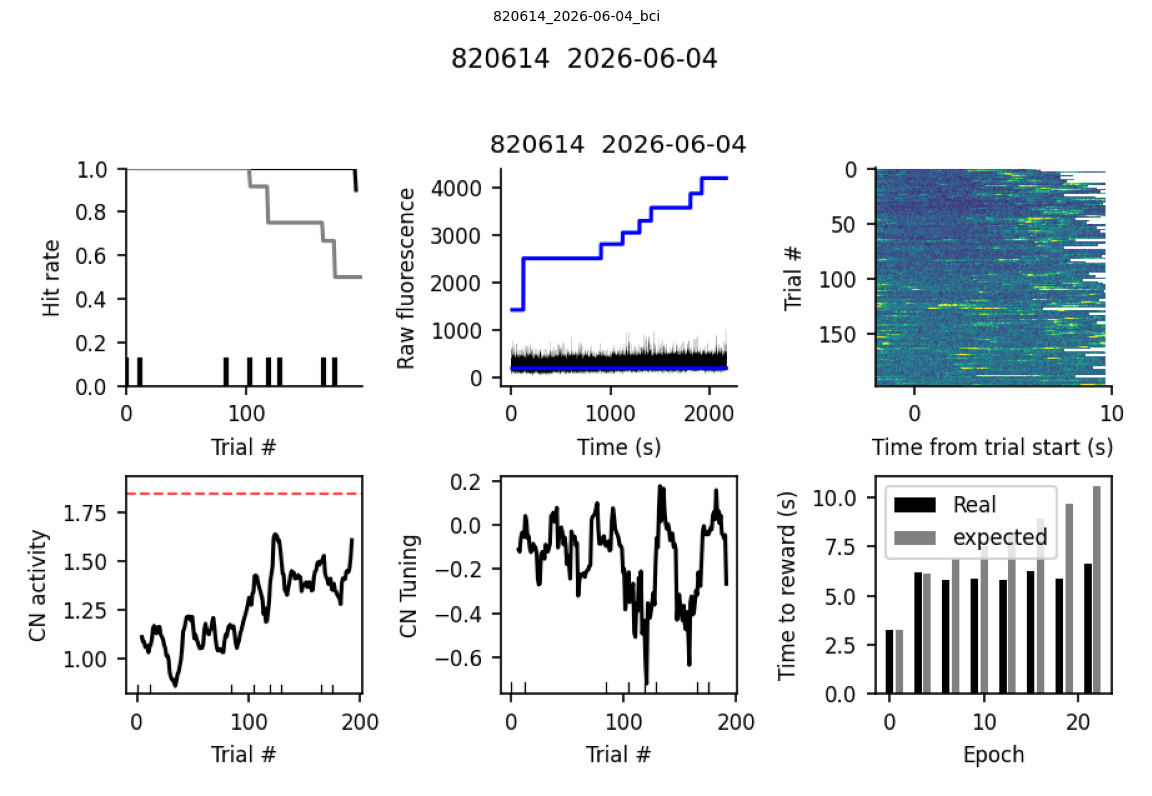

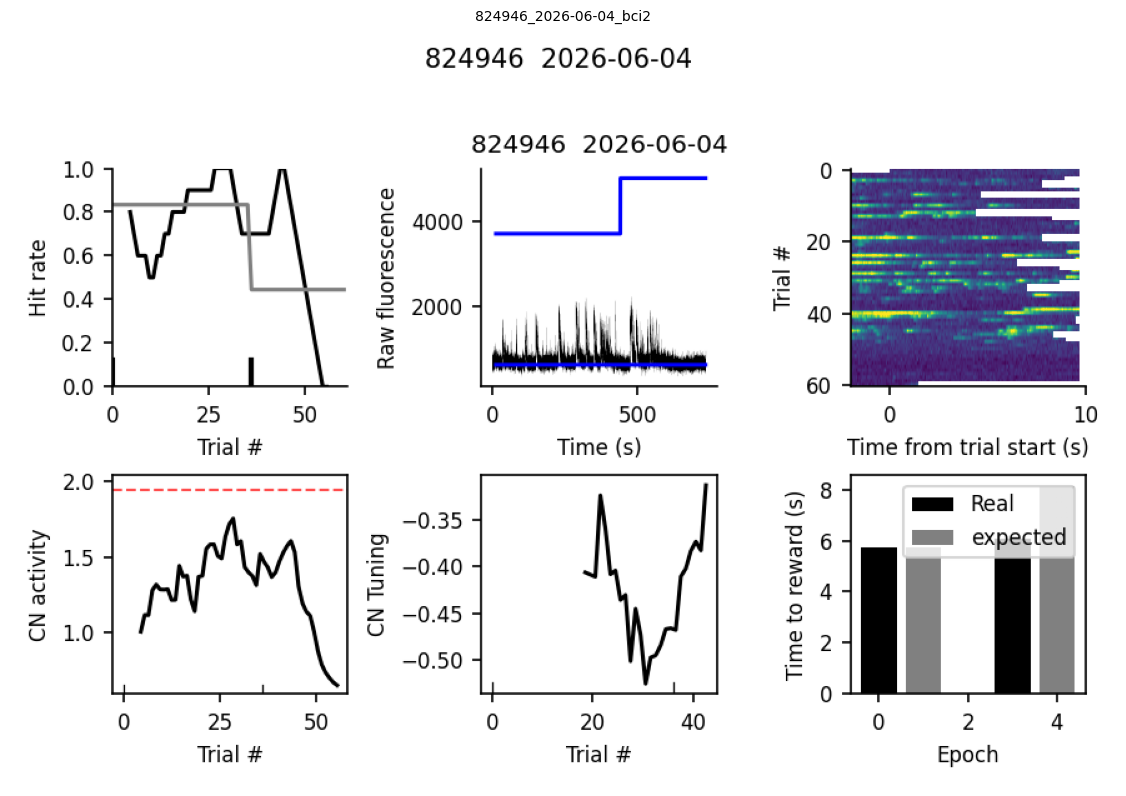

In [28]:
fig_dir = Path("/results") / "figures"
from matplotlib.image import imread

for subject, date, stem in TARGETS:
    session_tag = f"{subject}_{date}_{stem}"
    png = fig_dir / f"{session_tag}_fig_00.png"
    if png.exists():
        img = imread(str(png))
        fig, ax = plt.subplots(figsize=(12, 8))
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(session_tag, fontsize=10)
        plt.tight_layout()
        plt.show()
    else:
        print(f"  No fig_00 for {session_tag}")